In [48]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

In [50]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [54]:
#Standardization of data
mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)

X_std = (X - mean_X) / std_X

# Check the first few standardized values
print('First 5 standardized data points:\n', X_std[:5])

First 5 standardized data points:
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [56]:
# Step 3: Calculate the mean vectors for each class
mean_vectors = []
for cl in range(3):
    mean_vectors.append(np.mean(X_std[y == cl], axis=0))
    print(f'Mean Vector class {cl}: {mean_vectors[cl]}')

Mean Vector class 0: [-1.01457897  0.85326268 -1.30498732 -1.25489349]
Mean Vector class 1: [ 0.11228223 -0.66143204  0.28532388  0.1667341 ]
Mean Vector class 2: [ 0.90229674 -0.19183064  1.01966344  1.08815939]


In [58]:
# # Step 4: Compute the within-class scatter matrix S_W

# S_W = np.zeros((4, 4))
# for cl, mv in zip(range(3), mean_vectors):
#     class_scatter = np.zeros((4, 4))
#     for row in X_std[y == cl]:
#         row, mv = row.reshape(4, 1), mv.reshape(4, 1)  # Make row and mv column vectors
#         class_scatter += (row - mv).dot((row - mv).T)  # Compute scatter matrix
#     S_W += class_scatter  # Sum all class scatter matrices

# print('Within-class Scatter Matrix (S_W):\n', S_W)

In [60]:
# Step 4 :Initialize list to store covariance matrices for each class
cov_matrices = []

for cl, mv in zip(range(3), mean_vectors):
    # Initialize class scatter matrix (covariance matrix)
    class_scatter = np.zeros((4, 4))
    
    # Iterate over all data points in class 'cl'
    for row in X_std[y == cl]:
        row, mv = row.reshape(4, 1), mv.reshape(4, 1)  # Make row and mv column vectors
        # Compute (row - mean_vector) for each sample
        class_scatter += (row - mv).dot((row - mv).T)
    
    # Divide by (n_class - 1) to get covariance matrix (Bessel's correction)
    cov_matrix = class_scatter / (X_std[y == cl].shape[0] - 1)
    cov_matrices.append(cov_matrix)  # Store covariance matrix

# Print the covariance matrix for each class
for i, cov_matrix in enumerate(cov_matrices):
    print(f'Covariance Matrix for class {i}:\n', cov_matrix)


Covariance Matrix for class 0:
 [[0.18241804 0.27673866 0.01126355 0.0164769 ]
 [0.27673866 0.76142015 0.01530537 0.02817403]
 [0.01126355 0.01530537 0.0097429  0.00454089]
 [0.0164769  0.02817403 0.00454089 0.01924361]]
Covariance Matrix for class 1:
 [[0.39116717 0.23759815 0.12595945 0.08896617]
 [0.23759815 0.52179471 0.10814155 0.12485374]
 [0.12595945 0.10814155 0.07133456 0.05469228]
 [0.08896617 0.12485374 0.05469228 0.0677593 ]]
Covariance Matrix for class 2:
 [[0.59364215 0.26152874 0.20887174 0.07830273]
 [0.26152874 0.55112336 0.09339157 0.14432078]
 [0.20887174 0.09339157 0.09839686 0.0365287 ]
 [0.07830273 0.14432078 0.0365287  0.1307024 ]]


In [62]:
# Step 5 :Initialize within-class scatter matrix (S_W)
S_W = np.zeros((4, 4))

for i, cov_matrix in enumerate(cov_matrices):
    # Number of data points in class i
    n_class = X_std[y == i].shape[0]
    
    # Add the scaled covariance matrix to within-class scatter matrix
    S_W += (n_class - 1) * cov_matrix  # Scaling by (n_class - 1) to account for total data
    
print('Within-class Scatter Matrix (S_W):\n', S_W)

Within-class Scatter Matrix (S_W):
 [[57.19414039 38.01741201 16.95864185  9.00354437]
 [38.01741201 89.88257294 10.62508571 14.57007861]
 [16.95864185 10.62508571  8.79424214  4.69233162]
 [ 9.00354437 14.57007861  4.69233162 10.66756048]]


In [64]:
# Step 6: Compute the between-class scatter matrix S_B

overall_mean = np.mean(X_std, axis=0).reshape(4, 1)
S_B = np.zeros((4, 4))
for i, mean_vec in enumerate(mean_vectors):
    n = X_std[y == i, :].shape[0]  # Number of samples in class
    mean_vec = mean_vec.reshape(4, 1)  # Make mean vector a column vector
    S_B += n * (mean_vec - overall_mean).dot((mean_vec - overall_mean).T)

print('Between-class Scatter Matrix (S_B):\n', S_B)

Between-class Scatter Matrix (S_B):
 [[ 92.80585961 -55.65287963 113.80442453 113.68762457]
 [-55.65287963  60.11742706 -74.89110136 -69.48896849]
 [113.80442453 -74.89110136 141.20575786 139.73748309]
 [113.68762457 -69.48896849 139.73748309 139.33243952]]


In [66]:
# Step 7: Solve the generalized eigenvalue problem for inv(S_W) * S_B

eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

In [68]:
# Step 8: Sort eigenvectors by eigenvalues in descending order

eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]
eig_pairs = sorted(eig_pairs, key=lambda k: k[0], reverse=True)

In [72]:
# Select the top 2 eigenvectors for 2D transformation

W = np.hstack((eig_pairs[0][1].reshape(4, 1), eig_pairs[1][1].reshape(4, 1)))
print('LDA Projection Matrix (W):\n', W)

LDA Projection Matrix (W):
 [[-0.15128777  0.00693578]
 [-0.14733266  0.32786115]
 [ 0.85598541 -0.57170517]
 [ 0.47190474  0.75207191]]


In [74]:
# Step 9: Project the data onto the new LDA space

X_lda = X_std.dot(W)

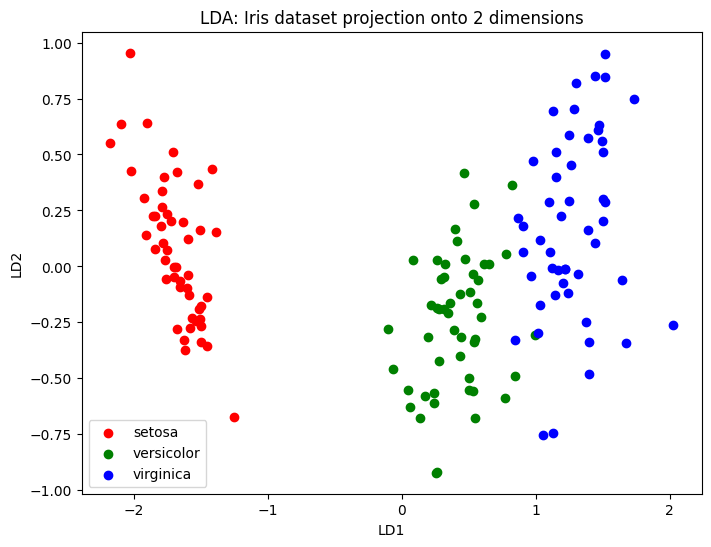

In [76]:
# Step 10: Visualize the LDA results

plt.figure(figsize=(8,6))
colors = ['r', 'g', 'b']
for label, color, target_name in zip([0, 1, 2], colors, target_names):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], c=color, label=target_name)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA: Iris dataset projection onto 2 dimensions')
plt.legend(loc='best')
plt.show()

Mean of standardized data (should be close to 0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Variance of standardized data (should be 1): [1. 1. 1. 1.]
Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]
Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]
Sorted Eigenvalues:
 [2.93808505 0.9201649  0.14774182 0.02085386]
Sorted Eigenvectors:
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]
Transformed Data (first 5 

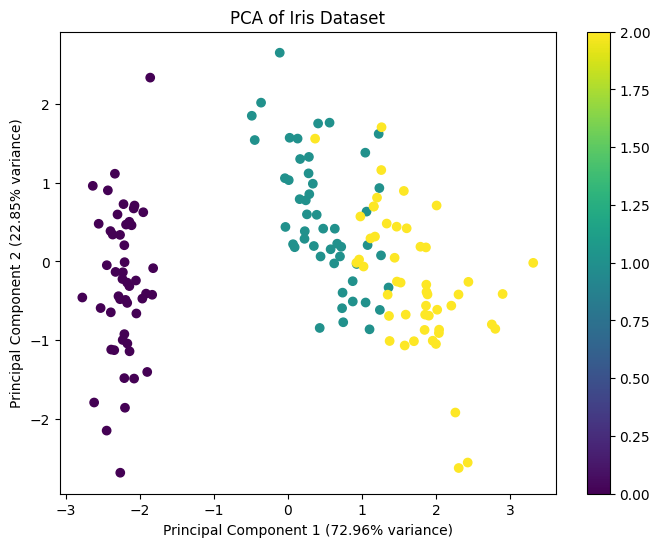

In [80]:
# Standardize the data (mean = 0, variance = 1)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_standardized = (X - X_mean) / X_std

print("Mean of standardized data (should be close to 0):", np.mean(X_standardized, axis=0))
print("Variance of standardized data (should be 1):", np.var(X_standardized, axis=0))# Calculate the covariance matrix
n_samples = X_standardized.shape[0]
cov_matrix= (1 / (n_samples - 1)) * np.dot(X_standardized.T, X_standardized)

print("Covariance Matrix:\n", cov_matrix)
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
# Sort eigenvalues and corresponding eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:\n", sorted_eigenvalues)
print("Sorted Eigenvectors:\n", sorted_eigenvectors)
# Calculate explained variance ratios
explained_variance_ratios = sorted_eigenvalues / np.sum(eigenvalues)
explained_variance_1 = explained_variance_ratios[0]
explained_variance_2 = explained_variance_ratios[1]# Select the top 2 eigenvectors (principal components)
top_2_eigenvectors = sorted_eigenvectors[:, :2]

# Project the data onto the new 2D space
X_pca = np.dot(X_standardized, top_2_eigenvectors)

print("Transformed Data (first 5 samples):\n", X_pca[:5])
# Visualize the two principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel(f'Principal Component 1 ({explained_variance_1:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_2:.2%} variance)')
plt.title('PCA of Iris Dataset')
plt.colorbar()
plt.show()
